# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


In [ ]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


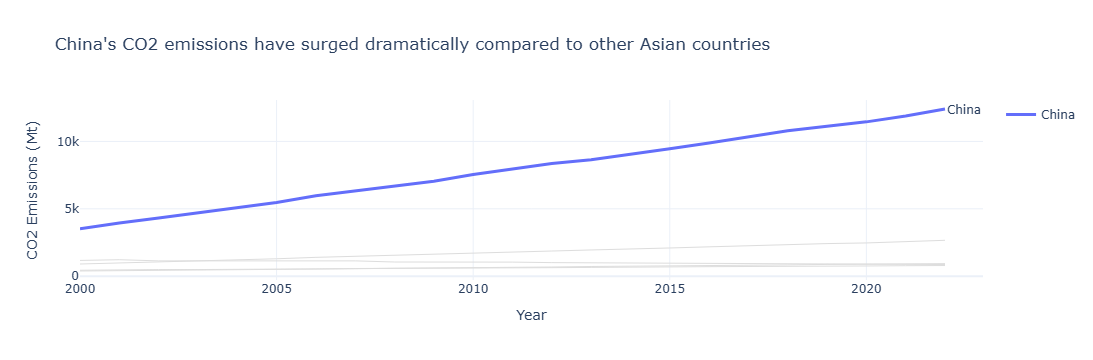

In [4]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_csv('co2_emissions.csv')

# Filter for Asia
asia_df = df[df['Region'] == 'Asia']

# Choose a country to highlight
highlight_country = "China"

# Create figure
fig = go.Figure()

# Loop through countries
for country in asia_df['Country'].unique():
    country_df = asia_df[asia_df['Country'] == country]
    
    if country == highlight_country:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines',
            line=dict(width=3),
            name=country,
        ))
        
        # Add direct label at end of line
        fig.add_annotation(
            x=country_df['Year'].iloc[-1],
            y=country_df['CO2_Mt'].iloc[-1],
            text=country,
            showarrow=False,
            xanchor='left',
            font=dict(size=12)
        )
    else:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines',
            line=dict(color='#DDDDDD', width=1),
            showlegend=False
        ))

# Insight title
fig.update_layout(
    title=f"{highlight_country}'s CO2 emissions have surged dramatically compared to other Asian countries",
    xaxis_title="Year",
    yaxis_title="CO2 Emissions (Mt)",
    template="plotly_white"
)

fig.show()


Title : China’s emissions surge has reshaped Asia’s CO₂ trajectory

Insight:
China’s emissions rise far more sharply than other Asian countries, dominating the regional trend.
Most other countries show gradual increases or relatively stable patterns.
This creates a widening gap between China and the rest of Asia over time.
The regional trajectory is therefore heavily skewed by one major emitter.
Smaller countries’ trends become less visible due to this imbalance.

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


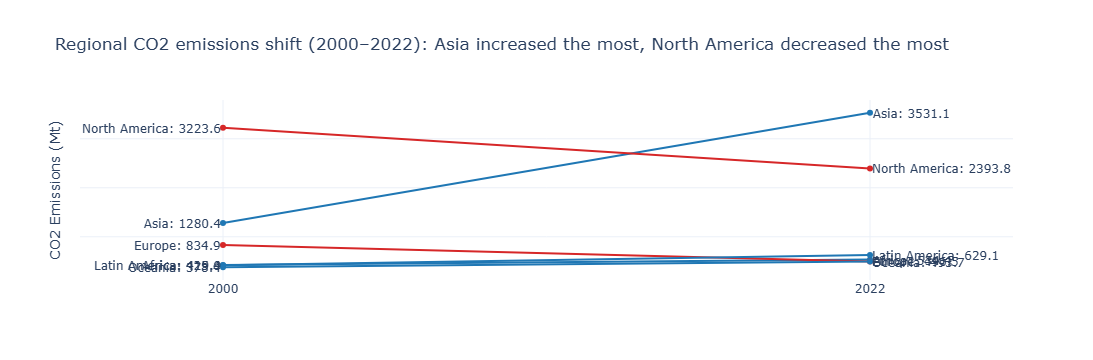

In [5]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_csv('co2_emissions.csv')

# Aggregate: average emissions per region per year
region_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

# Filter for 2000 and 2022
slope_df = region_avg[region_avg['Year'].isin([2000, 2022])]

# Pivot for easier comparison
pivot_df = slope_df.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()

# Create figure
fig = go.Figure()

# Colors
increase_color = "#1f77b4"   # blue
decrease_color = "#d62728"   # red

# Track biggest changes for title insight
pivot_df['change'] = pivot_df[2022] - pivot_df[2000]
most_increase = pivot_df.loc[pivot_df['change'].idxmax()]
most_decrease = pivot_df.loc[pivot_df['change'].idxmin()]

# Plot each region
for _, row in pivot_df.iterrows():
    region = row['Region']
    y0 = row[2000]
    y1 = row[2022]
    
    color = increase_color if y1 > y0 else decrease_color
    
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[y0, y1],
        mode='lines+markers',
        line=dict(color=color, width=2),
        showlegend=False
    ))
    
    # Labels at both ends
    fig.add_annotation(x=2000, y=y0,
                       text=f"{region}: {y0:.1f}",
                       showarrow=False,
                       xanchor='right')
    
    fig.add_annotation(x=2022, y=y1,
                       text=f"{region}: {y1:.1f}",
                       showarrow=False,
                       xanchor='left')

# Layout
fig.update_layout(
    title=(
        f"Regional CO2 emissions shift (2000–2022): "
        f"{most_increase['Region']} increased the most, "
        f"{most_decrease['Region']} decreased the most"
    ),
    xaxis=dict(
        tickvals=[2000, 2022],
        title=""
    ),
    yaxis=dict(
        showticklabels=False,  # remove y-axis labels
        title="CO2 Emissions (Mt)"
    ),
    template="plotly_white"
)

fig.show()

Title : Emissions growth is uneven across regions, with Asia rising fastest while some regions stabilize or decline

Insight: Asia shows the largest increase in average emissions from 2000 to 2022.
Some regions grow moderately, while others remain stable or decline slightly.
The gap between high- and low-emission regions widens over time.
This reflects uneven industrial growth and differing policy impacts.
Overall, global emissions trends are increasingly driven by a few fast-growing regions.